# Importing a trained model

## Direct import from a serialized model

In [1]:
import tensorflow as tf
import os
import pandas as pd
import IPython.display as ips
from model import Model
from data_utils import import_hparams, rasterize, rasterize_dev
from utils import get_dot_seq_from_dx_dy

gpus = '1'
hparams_path = 'ckpt/example/hparams.yaml'
model_path = 'ckpt/example/example-epoch-40-it-2583.tf'

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = gpus
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    
hparams = import_hparams(hparams_path, v_type='cartesian')
model = Model(hparams)
model.load_weights(model_path)

gif_path = 'test.gif'
png_path = 'test.png'

w_img = model.hp['w_img']
h_img = model.hp['h_img']
dt = model.hp['dt']
stroke_width = model.hp['stroke_width']

dx_norm = model.dx_norm.numpy()
dy_norm = model.dy_norm.numpy()
dx_mean = 0
dy_mean = 0

2022-05-19 18:16:55.781513: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2022-05-19 18:16:56.521226: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1525] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9647 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 Ti, pci bus id: 0000:5e:00.0, compute capability: 7.5


In [3]:
def generate(model, digit, bias=0):
    dx_seq, dy_seq, eos_seq, eod_seq = model.infer(digit, eod_stop=True, bias=bias)
    df_v_synt = pd.DataFrame({'dx_seq':dx_seq*dx_norm + dx_mean, 'dy_seq':dy_seq*dy_norm + dy_mean, 'eos_seq':eos_seq, 'eod_seq':eod_seq})
    df_dots_synt = get_dot_seq_from_dx_dy(df_v_synt, w_img, h_img, dt)
    np_images = rasterize_dev(df_dots_synt, w_img, h_img, dt, stroke_width, gif_path, png_path)

2022-05-19 18:16:58.017265: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8201


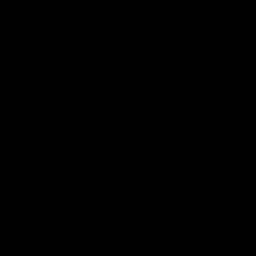

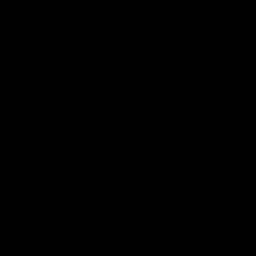

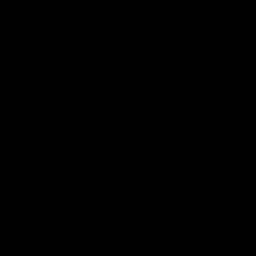

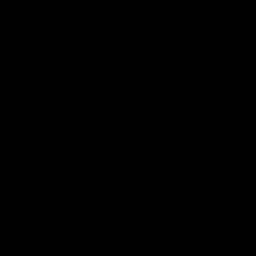

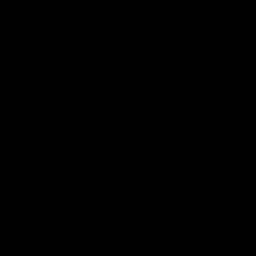

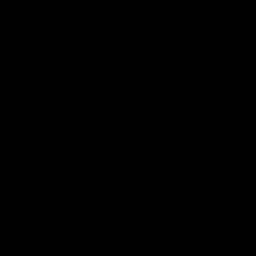

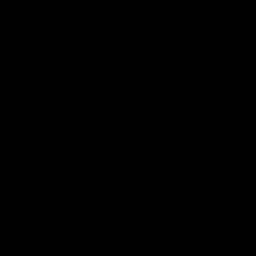

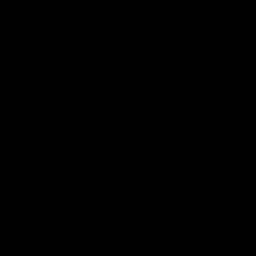

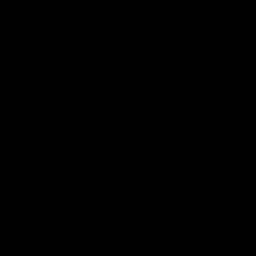

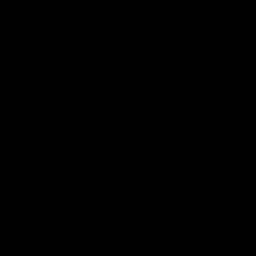

In [4]:
for digit in range(10):
    generate(model, digit=digit, bias=0)
    ips.display(ips.Image(filename=gif_path))